# 03 - Feature Selection y Aseguramiento de Calidad (Nulos)

Este notebook tiene como objetivo justificar matemáticamente cada variable que entra al modelo predictivo. Reemplazamos la eliminación manual con pruebas estadísticas formales.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# 1. Cargar datos
print("Cargando datos...")
master = pd.read_parquet('../../data/interim/master_merged.parquet')

# Filtramos filas sin target (Desnutrición)
master = master.dropna(subset=['HC70']).copy()
master['TARGET_DESNUTRICION'] = (master['HC70'] < -2.0).astype(int)

# Eliminamos variables de Fuga (Leakage) e identificadores que sabemos que no son predictivos
leakage_cols = [
    'HC0', 'HVIDX', 'HV112', 'HV001', 'HV002', 'HV002A', 'NCONGLOME', 'CODCCPP', 'NOMCCPP', 'ID1',
    'HC2', 'HC3', 'HC4', 'HC5', 'HC6', 'HC7', 'HC8', 'HC9', 'HC10', 'HC11', 'HC12', 'HC13', 
    'HC15', 'HC16', 'HC19', 'HC30', 'HC31', 'HC32', 'HC33', 'HC71', 'HC72', 'HC73', 'HC55', 'HC70',
    'HV004', 'HV005', 'hv005', 'HV008', 'HV015', 'HV021', 'HV022', 
    'HV024', 'SHREGION', 'SHPROVIN', 'SHDISTRI', 'SHSEMES', 
    'HV120', 'HV010', 'HV035', 'HC64', 'HV114', 'HC51', 'HC60', 
    'HV218', 'HV117', 'UBIGEO', 'LONGITUDX', 'LATITUDY', 'year', 'HHID'
]
cols_to_drop = [c for c in leakage_cols if c in master.columns]
df_clean = master.drop(columns=cols_to_drop)

print(f"Dimensiones base: {df_clean.shape}")


Cargando datos...
Dimensiones base: (285284, 125)


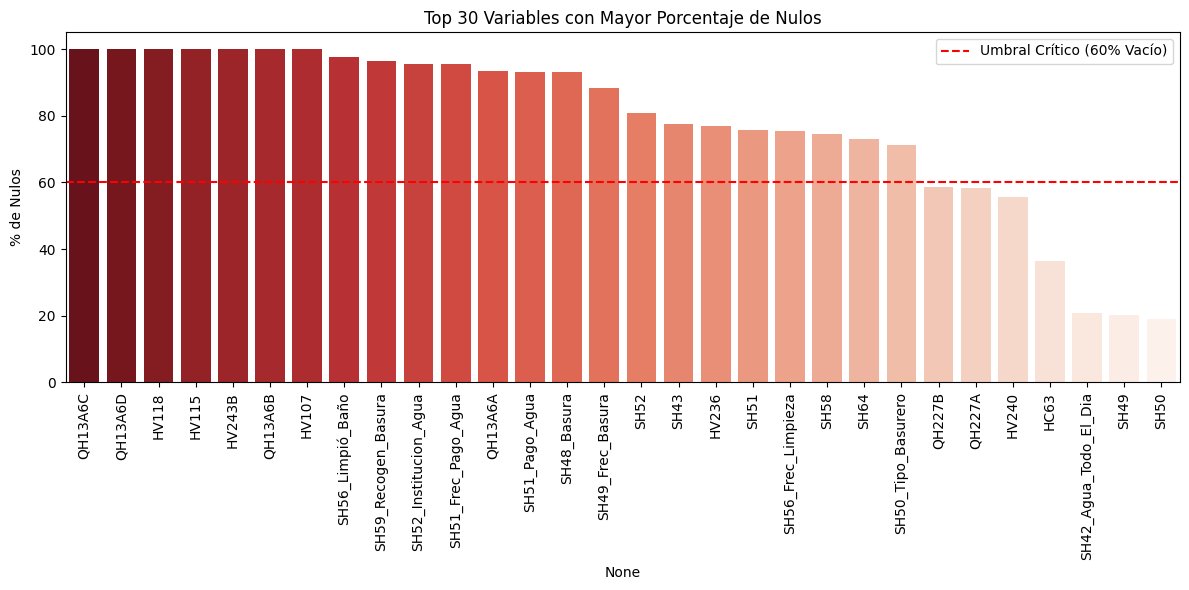

Se eliminaron 23 variables por superar el 60% de nulos.


In [2]:
# 2. AUDITORÍA VISUAL DE NULOS
# Calculamos el porcentaje de nulos por columna
null_percentages = (df_clean.isnull().sum() / len(df_clean)) * 100
null_percentages = null_percentages[null_percentages > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=null_percentages.index[:30], y=null_percentages.values[:30], palette='Reds_r')
plt.axhline(y=60, color='r', linestyle='--', label='Umbral Crítico (60% Vacío)')
plt.title('Top 30 Variables con Mayor Porcentaje de Nulos')
plt.xticks(rotation=90)
plt.ylabel('% de Nulos')
plt.legend()
plt.tight_layout()
plt.show()

# Ejecutamos la guillotina objetiva (> 60% nulos fuera)
variables_basura = null_percentages[null_percentages > 60].index.tolist()
df_clean = df_clean.drop(columns=variables_basura)
print(f"Se eliminaron {len(variables_basura)} variables por superar el 60% de nulos.")


Pares de variables altamente colineales detectados matemáticamente (>0.85):
➜ HV105 y HC1 (Correlación: 0.98)
➜ HV108 y HV106 (Correlación: 0.89)
➜ HV109 y HV106 (Correlación: 0.98)
➜ HV109 y HV108 (Correlación: 0.97)
➜ HV012 y HV009 (Correlación: 0.96)
➜ HV013 y HV009 (Correlación: 0.94)
➜ HV013 y HV012 (Correlación: 0.90)


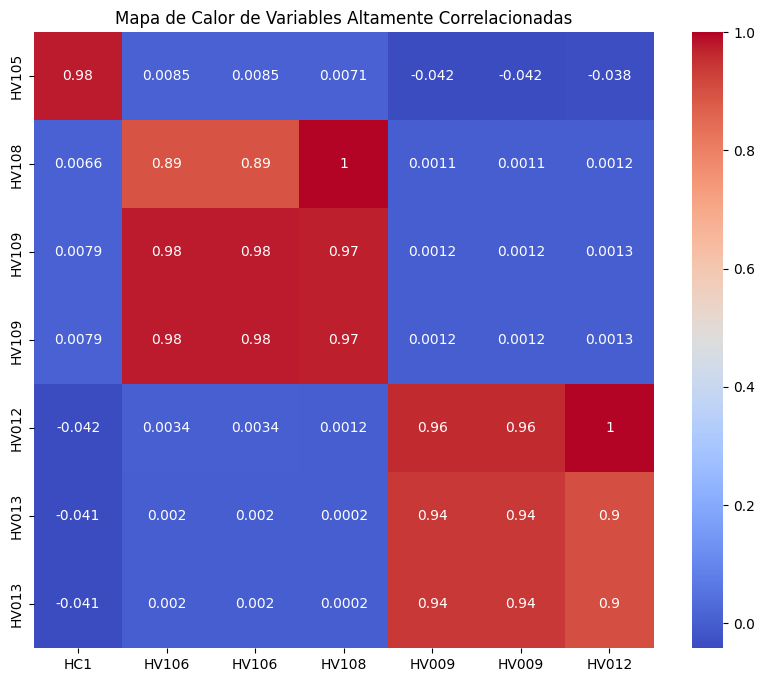

In [3]:
# 3. ANÁLISIS DE COLINEALIDAD (Correlación)
# Seleccionamos solo las numéricas para la matriz
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('TARGET_DESNUTRICION')

corr_matrix = df_clean[num_cols].corr()

# Extraer pares altamente correlacionados (> 0.85)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Pares de variables altamente colineales detectados matemáticamente (>0.85):")
for pair in high_corr_pairs:
    print(f"➜ {pair[0]} y {pair[1]} (Correlación: {pair[2]:.2f})")
    
# Visualizamos un mapa de calor simplificado
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[[p[0] for p in high_corr_pairs[:10]], [p[1] for p in high_corr_pairs[:10]]], annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Variables Altamente Correlacionadas')
plt.show()


In [6]:
# 4. PRUEBAS ESTADÍSTICAS BIVARIADAS (P-Values)
# Verificamos si cada variable tiene una relación estadísticamente significativa con la Desnutrición
from scipy.stats import chi2_contingency, kruskal

p_values = {}
features = df_clean.drop(columns=['TARGET_DESNUTRICION'])
target = df_clean['TARGET_DESNUTRICION']

for col in features.columns:
    if pd.api.types.is_numeric_dtype(features[col]):
        # Kruskal-Wallis (alternativa no paramétrica a ANOVA)
        group1 = features.loc[target == 0, col].dropna()
        group2 = features.loc[target == 1, col].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, p = kruskal(group1, group2)
            p_values[col] = p
    else:
        # Chi-Cuadrado para categóricas
        contingency = pd.crosstab(features[col], target)
        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            stat, p, dof, expected = chi2_contingency(contingency)
            p_values[col] = p

p_df = pd.DataFrame(list(p_values.items()), columns=['Variable', 'P_Value'])
p_df['Relevante'] = p_df['P_Value'] < 0.05 # Rechazamos hipótesis nula

print("Prueba Estadística Bivariada Completada.")
print(f"Variables RELEVANTES (P-value < 0.05): {p_df['Relevante'].sum()}")
print(f"Variables IRRELEVANTES (P-value >= 0.05): {(~p_df['Relevante']).sum()}")

# Muestra de las irrelevantes
print("\nVariables estadísticamente irrelevantes para la desnutrición:")
print(p_df[~p_df['Relevante']].head(10))


Prueba Estadística Bivariada Completada.
Variables RELEVANTES (P-value < 0.05): 92
Variables IRRELEVANTES (P-value >= 0.05): 8

Variables estadísticamente irrelevantes para la desnutrición:
   Variable   P_Value  Relevante
0       HC1  0.418598      False
11    HV105  0.483376      False
13    HV108  0.112176      False
19    HV122  0.072578      False
49    HV225  0.246274      False
55   HV237C  0.196063      False
57   HV237E  1.000000      False
63   HV243C  0.490507      False


In [7]:
# 5. IMPORTANCIA MULTIVARIADA (XGBoost Feature Selection)
# Las pruebas bivariadas analizan variables de 1 en 1. XGBoost las analiza todas juntas.
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Preparamos una copia rápida convirtiendo categóricas
X_test_xgb = features.copy()
for col in X_test_xgb.columns:
    if not pd.api.types.is_numeric_dtype(X_test_xgb[col]):
        X_test_xgb[col] = X_test_xgb[col].astype(str).astype('category')

# Entrenamos un árbol rápido (sin balanceo, solo para ver poder puro)
print("Entrenando Árbol de Selección...")
xgb_selector = xgb.XGBClassifier(n_estimators=100, random_state=42, enable_categorical=True, tree_method='hist')
xgb_selector.fit(X_test_xgb, target)

# Resultados
importances = xgb_selector.feature_importances_
importance_df = pd.DataFrame({'Variable': X_test_xgb.columns, 'Importancia': importances})
importance_df = importance_df.sort_values('Importancia', ascending=False)

print("Las 10 variables con CERO poder predictivo en conjunto (Basura algorítmica):")
print(importance_df[importance_df['Importancia'] == 0]['Variable'].tolist())


Entrenando Árbol de Selección...
Las 10 variables con CERO poder predictivo en conjunto (Basura algorítmica):
['HV128', 'HV109', 'HV108', 'HV103', 'HV124', 'HV237X', 'HV237E']
